# 05 — Evaluation, Ablations and Scenario Simulation

One-step loss is not the product. The product is a useful, physically credible rollout under interventions.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent
import sys
sys.path.insert(0, str(ROOT / 'src'))

In [2]:
run = ROOT/'artifacts/runs/reference_gru'
metrics = json.loads((run/'metrics.json').read_text())
ablations = pd.DataFrame(json.loads((run/'ablations.json').read_text()))
metrics['speed_mae_mps'] * 3.6, ablations[['ablation','speed_mae_mps']]

(13.713030910491943,
              ablation  speed_mae_mps
 0  state_plus_actions       0.195782
 1          state_only       0.224532
 2        full_context       0.334710
 3          no_weather       0.336097
 4   no_track_geometry       0.383152)

## Horizon error

At step 1, the model starts from real history. At later steps, it consumes its own imperfect predictions. That is why rollout error usually grows. Plotting error against horizon reveals whether a model is useful for 0.2 seconds, 2 seconds or 20 seconds.

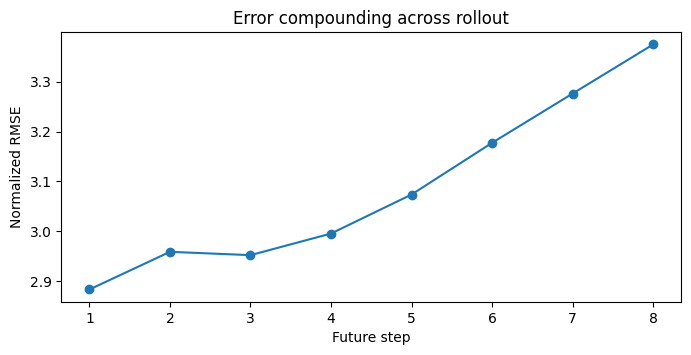

In [3]:
plt.figure(figsize=(8,3.5))
plt.plot(np.arange(1,len(metrics['horizon_rmse'])+1), metrics['horizon_rmse'], marker='o')
plt.xlabel('Future step'); plt.ylabel('Normalized RMSE'); plt.title('Error compounding across rollout'); plt.show()

## Ablation logic

An ablation removes one source of information while preserving data split, model class, training budget and metric. It answers a causal engineering question such as: “Does weather context improve held-out-session prediction?”

In [4]:
display(ablations[['ablation','speed_mae_mps','overall_mae']])

,ablation,speed_mae_mps,overall_mae
0,state_plus_actions,0.195782,0.234400
1,state_only,0.224532,0.268778
2,full_context,0.334710,0.408137
3,no_weather,0.336097,0.364285
4,no_track_geometry,0.383152,1.916630


## Intervene on the future

A scenario should modify only intended action/context fields. It must not secretly rewrite target states. This distinction separates simulation from data editing.

In [5]:
from apexsim.simulation import Scenario, apply_scenario
from apexsim.contracts import MODEL_INPUT_COLUMNS
values = np.ones((5,len(MODEL_INPUT_COLUMNS)), dtype=np.float32) * .5
changed = apply_scenario(values, Scenario(throttle_scale=1.2, rain_delta=.2))
idx={name:i for i,name in enumerate(MODEL_INPUT_COLUMNS)}
print('throttle before/after', values[0,idx['throttle']], changed[0,idx['throttle']])
print('rain before/after', values[0,idx['rainfall']], changed[0,idx['rainfall']])

throttle before/after 0.5 0.6
rain before/after 0.5 0.7


### Evaluation stack
1. One-step feature error.
2. Multi-step horizon curves.
3. Physical constraints.
4. Calibration/coverage for stochastic models.
5. Track/driver/session holdouts.
6. Counterfactual sanity checks.
7. Operational usefulness: does the result change a race-engineering decision?